# Notebook 04 — KaelvorNet Improvement Ablation

# Full Leave-One-Subject-Out Ablation Study (BCI-IV 2a)

---

## Purpose

Isolates which of KaelvorNet's three components -- Euclidean Alignment (EA), the
gradient-reversal domain head (GRL), and the subject adapter -- is actually responsible for
any cross-subject generalization improvement, rather than just reporting "the combination
worked." Runs the full 5-variant x 9-held-out-subject sweep (45 training runs total) and
reports per-subject and averaged results, plus a paired comparison against the EEGNet baseline.

**This is a standalone notebook** -- self-contained, doesn't depend on the KaelvorNet or
baseline notebooks' in-memory state. It only needs the same preprocessed `.fif` files.

## Before running this notebook

1. **Add Input -> Notebooks -> your preprocessing notebook** (must be a completed
   "Save & Run All (Commit)" run, providing `preprocessed_dataset/A0X/A0XT.fif` / `A0XE.fif`).
2. **Add Input -> Datasets -> raw 2a dataset / true_labels bundle**, if you want the official
   T -> E split (`A0XE.mat` files). Falls back to a 70/30 split within T otherwise (a larger
   held-out fraction than the baseline notebooks, since here it's standing in for the
   evaluation set across every ablation variant, not just one model).

## Variants tested

| Variant | EA | GRL | Adapter |
|---|---|---|---|
| EEGNet baseline | No | No | No |
| + EA only | Yes | No | No |
| + EA + GRL | Yes | Yes | No |
| + EA + GRL + adapter (full KaelvorNet) | Yes | Yes | Yes |
| + GRL + adapter, no EA | No | Yes | Yes |

## Protocol

For each of the 9 subjects held out in turn: pretrain on the other 8 subjects' T-files (with
each variant's components toggled accordingly), then evaluate **zero-shot** on the held-out
subject's E-file (no fine-tuning at all) -- this is the cleanest, most literal measurement of
cross-subject generalization, and isolates component contribution from the confound of
few-shot adaptation quality.

**Runtime note:** 45 training runs (9 subjects x 5 variants) will take a while even on a
Kaggle GPU. `n_epochs` is set lower here (60) than the main KaelvorNet notebook's evaluations
(100) to keep this tractable -- treat this as an ablation *screening* pass; if you want
publication-quality numbers, increase `n_epochs` and expect proportionally longer runtime.

In [1]:
# Kaggle notebooks don't have mne preinstalled by default
!pip install -q mne

In [2]:
# ==========================================================
# Imports
# ==========================================================

import re
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
import mne

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.autograd import Function

from sklearn.metrics import accuracy_score, cohen_kappa_score
from sklearn.model_selection import train_test_split
from scipy import stats
from scipy.linalg import fractional_matrix_power

import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [3]:
# ==========================================================
# Configuration — auto-discover inputs
# ==========================================================

INPUT_ROOT = Path("/kaggle/input")
OUTPUT_PATH = Path("/kaggle/working")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

fif_files = sorted(INPUT_ROOT.rglob("*.fif"))
mat_search_root = INPUT_ROOT

print(f"Found {len(fif_files)} preprocessed .fif file(s):")
for f in fif_files[:10]:
    print(" ", f)
if len(fif_files) > 10:
    print(f"  ... and {len(fif_files) - 10} more")

if not fif_files:

    print("\nNo .fif files found. Everything currently under /kaggle/input:\n")
    if INPUT_ROOT.exists():
        for p in sorted(INPUT_ROOT.rglob("*")):
            print(" ", p)
    else:
        print("  /kaggle/input does not exist -- no inputs attached at all.")

    raise FileNotFoundError(
        "No .fif files found under /kaggle/input. Make sure the preprocessing notebook was "
        "committed via 'Save Version -> Save & Run All (Commit)' and added here as a Notebook "
        "input (see intro cell)."
    )

CUE_CODE_TO_LABEL = {"769": 0, "770": 1, "771": 2, "772": 3}
CLASS_NAMES = {0: "Left Hand", 1: "Right Hand", 2: "Foot", 3: "Tongue"}

mi_files = [f for f in fif_files if f.stem.upper().endswith("T")]
eval_files = [f for f in fif_files if f.stem.upper().endswith("E")]

subjects_covered = sorted({f.stem[:-1] for f in mi_files})
subject_ids_all = {sid: i for i, sid in enumerate(subjects_covered)}
n_subjects_total = len(subject_ids_all)

print(f"\nSubjects with a training file ({n_subjects_total}): {subjects_covered}")

Found 18 preprocessed .fif file(s):
  /kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A01/A01E.fif
  /kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A01/A01T.fif
  /kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A02/A02E.fif
  /kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A02/A02T.fif
  /kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A03/A03E.fif
  /kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A03/A03T.fif
  /kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A04/A04E.fif
  /kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A04/A04T.fif
  /kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A05/A05E.fif
  /kaggle/input/notebooks/sababahoque

In [4]:
# ==========================================================
# Epoch extraction + label lookup
# ==========================================================

def extract_epochs(fif_file):

    raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
    events, event_id = mne.events_from_annotations(raw, verbose=False)
    cue_id = {k: v for k, v in event_id.items() if k in CUE_CODE_TO_LABEL}

    if not cue_id:
        raise ValueError(f"No motor-imagery cue codes found in {fif_file.name}.")

    epochs = mne.Epochs(
        raw, events, event_id=cue_id, tmin=-0.5, tmax=4.0,
        baseline=(-0.5, 0), preload=True, reject_by_annotation=True, verbose=False
    )

    X = epochs.get_data()
    inv_cue_id = {v: k for k, v in cue_id.items()}
    y = np.array([CUE_CODE_TO_LABEL[inv_cue_id[c]] for c in epochs.events[:, 2]])

    return X, y


def extract_epochs_eval(fif_file):

    raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
    events, event_id = mne.events_from_annotations(raw, verbose=False)
    eval_cue_id = {k: v for k, v in event_id.items() if k == "783"}

    if not eval_cue_id:
        raise ValueError(f"No 'unknown' (783) cue markers found in {fif_file.name}.")

    epochs = mne.Epochs(
        raw, events, event_id=eval_cue_id, tmin=-0.5, tmax=4.0,
        baseline=(-0.5, 0), preload=True, reject_by_annotation=True, verbose=False
    )

    return epochs.get_data()


def find_true_labels(subject_id, search_root):

    candidates = list(Path(search_root).rglob(f"{subject_id}E.mat"))
    if not candidates:
        return None

    mat = sio.loadmat(candidates[0])
    key = "classlabel" if "classlabel" in mat else next(
        (k for k in mat if not k.startswith("__")), None
    )
    if key is None:
        return None

    return np.array(mat[key]).squeeze().astype(int) - 1

In [5]:
# ==========================================================
# Euclidean Alignment
# ==========================================================

def compute_alignment_matrix(X):

    n_trials, n_channels, n_samples = X.shape
    covs = np.array([(trial @ trial.T) / n_samples for trial in X])
    mean_cov = covs.mean(axis=0)

    return fractional_matrix_power(mean_cov, -0.5).real


def apply_alignment(X, R_inv_sqrt):

    return np.einsum("cd,ndt->nct", R_inv_sqrt, X)


def euclidean_align(X_ref, *X_others):

    R_inv_sqrt = compute_alignment_matrix(X_ref)
    aligned = [apply_alignment(X_ref, R_inv_sqrt)]
    for X in X_others:
        aligned.append(apply_alignment(X, R_inv_sqrt))

    return aligned

In [6]:
# ==========================================================
# Gradient Reversal Layer
# ==========================================================

class GradientReversalFunction(Function):

    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.lambda_ = lambda_
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.lambda_, None


class GradientReversalLayer(nn.Module):

    def __init__(self, lambda_=1.0):
        super().__init__()
        self.lambda_ = lambda_

    def forward(self, x):
        return GradientReversalFunction.apply(x, self.lambda_)

In [7]:
# ==========================================================
# KaelvorNet (same architecture as the main KaelvorNet notebook)
# ==========================================================

class EEGNetBackbone(nn.Module):

    def __init__(self, n_channels=22, n_samples=1126, sfreq=250, F1=8, D=2, F2=16, dropout=0.5):
        super().__init__()

        half_sfreq = max(int(sfreq // 2), 1)

        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, half_sfreq), padding=(0, half_sfreq // 2), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1 * D, (n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout),
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(F1 * D, F1 * D, (1, 16), padding=(0, 8), groups=F1 * D, bias=False),
            nn.Conv2d(F1 * D, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_samples)
            out = self.block2(self.block1(dummy))
            self.feature_dim = out.numel()

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.block1(x)
        x = self.block2(x)
        return x.flatten(start_dim=1)


class SubjectAdapter(nn.Module):

    def __init__(self, feature_dim):
        super().__init__()
        self.norm = nn.BatchNorm1d(feature_dim, affine=True)

    def forward(self, x):
        return self.norm(x)


class KaelvorNet(nn.Module):

    def __init__(self, n_channels=22, n_classes=4, n_samples=1126, sfreq=250,
                 n_subjects=9, use_domain_head=True, use_adapter=True, grl_lambda=1.0):
        super().__init__()

        self.use_domain_head = use_domain_head
        self.use_adapter = use_adapter

        self.backbone = EEGNetBackbone(n_channels=n_channels, n_samples=n_samples, sfreq=sfreq)
        feat_dim = self.backbone.feature_dim

        if use_adapter:
            self.adapter = SubjectAdapter(feat_dim)

        self.classifier = nn.Linear(feat_dim, n_classes)

        if use_domain_head:
            self.grl = GradientReversalLayer(lambda_=grl_lambda)
            self.domain_head = nn.Sequential(
                nn.Linear(feat_dim, 32),
                nn.ELU(),
                nn.Linear(32, n_subjects),
            )

    def set_grl_lambda(self, lambda_):
        if self.use_domain_head:
            self.grl.lambda_ = lambda_

    def forward(self, x, return_domain_logits=False):

        features = self.backbone(x)
        adapted = self.adapter(features) if self.use_adapter else features
        class_logits = self.classifier(adapted)

        if return_domain_logits and self.use_domain_head:
            domain_logits = self.domain_head(self.grl(features))
            return class_logits, domain_logits

        return class_logits

In [8]:
# ==========================================================
# Training Helper
# ==========================================================

def normalize(X, mean, std):
    return (X - mean) / std


def train_kaelvornet(X_train, y_train, subj_train, X_test, y_test, n_subjects,
                      use_domain_head=True, use_adapter=True,
                      n_epochs=60, batch_size=32, lr=1e-3, grl_lambda_max=1.0, verbose=False):

    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std = X_train.std(axis=(0, 2), keepdims=True) + 1e-8

    X_train_n = normalize(X_train, mean, std)
    X_test_n = normalize(X_test, mean, std)

    X_train_t = torch.tensor(X_train_n, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    subj_train_t = torch.tensor(subj_train, dtype=torch.long)
    X_test_t = torch.tensor(X_test_n, dtype=torch.float32).to(DEVICE)

    train_ds = TensorDataset(X_train_t, y_train_t, subj_train_t)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    model = KaelvorNet(
        n_channels=X_train.shape[1], n_classes=len(CLASS_NAMES), n_samples=X_train.shape[2],
        n_subjects=n_subjects, use_domain_head=use_domain_head, use_adapter=use_adapter,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    task_criterion = nn.CrossEntropyLoss()
    domain_criterion = nn.CrossEntropyLoss()

    model.train()

    for epoch in range(n_epochs):

        p = epoch / max(n_epochs - 1, 1)
        lambda_ = grl_lambda_max * (2.0 / (1.0 + np.exp(-10 * p)) - 1.0)
        model.set_grl_lambda(lambda_)

        epoch_loss = 0.0

        for xb, yb, sb in train_loader:

            xb, yb, sb = xb.to(DEVICE), yb.to(DEVICE), sb.to(DEVICE)
            optimizer.zero_grad()

            if use_domain_head:
                class_logits, domain_logits = model(xb, return_domain_logits=True)
                loss = task_criterion(class_logits, yb) + domain_criterion(domain_logits, sb)
            else:
                class_logits = model(xb)
                loss = task_criterion(class_logits, yb)

            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)

        if verbose and ((epoch + 1) % 20 == 0 or epoch == 0):
            print(f"      epoch {epoch+1}/{n_epochs}  loss={epoch_loss/len(train_ds):.4f}")

    model.eval()

    with torch.no_grad():
        preds = model(X_test_t).argmax(dim=1).cpu().numpy()

    acc = accuracy_score(y_test, preds)
    kappa = cohen_kappa_score(y_test, preds)

    return acc, kappa

---
## Full Ablation Sweep — All 9 Subjects x 5 Variants (45 runs)

In [9]:
# ==========================================================
# Full Ablation Sweep
# ==========================================================

ABLATION_VARIANTS = [
    {"name": "EEGNet baseline",        "use_ea": False, "use_domain_head": False, "use_adapter": False},
    {"name": "+ EA only",              "use_ea": True,  "use_domain_head": False, "use_adapter": False},
    {"name": "+ EA + GRL",             "use_ea": True,  "use_domain_head": True,  "use_adapter": False},
    {"name": "+ EA + GRL + adapter",   "use_ea": True,  "use_domain_head": True,  "use_adapter": True},
    {"name": "+ GRL + adapter, no EA", "use_ea": False, "use_domain_head": True,  "use_adapter": True},
]

N_EPOCHS_ABLATION = 60  # screening pass -- raise for publication-quality numbers

ablation_results = []

for held_out_id in subjects_covered:

    train_subject_ids = [s for s in subjects_covered if s != held_out_id]

    e_file_ho = next((f for f in eval_files if f.stem[:-1] == held_out_id), None)
    if e_file_ho is None:
        print(f"[{held_out_id}] Skipped entirely -- no matching *E file found.")
        continue

    true_labels = find_true_labels(held_out_id, mat_search_root)
    used_fallback = true_labels is None

    for variant in ABLATION_VARIANTS:

        X_pool, y_pool, subj_pool = [], [], []

        for sid in train_subject_ids:

            t_file = next(f for f in mi_files if f.stem[:-1] == sid)
            X_s, y_s = extract_epochs(t_file)

            if variant["use_ea"]:
                X_s, = euclidean_align(X_s)

            X_pool.append(X_s)
            y_pool.append(y_s)
            subj_pool.append(np.full(len(y_s), subject_ids_all[sid]))

        X_pool = np.concatenate(X_pool, axis=0)
        y_pool = np.concatenate(y_pool, axis=0)
        subj_pool = np.concatenate(subj_pool, axis=0)

        if used_fallback:
            t_file_ho = next(f for f in mi_files if f.stem[:-1] == held_out_id)
            X_ho, y_ho = extract_epochs(t_file_ho)
            _, X_ho_test, _, y_ho_test = train_test_split(
                X_ho, y_ho, test_size=0.7, stratify=y_ho, random_state=SEED
            )
        else:
            X_ho_test = extract_epochs_eval(e_file_ho)
            if len(true_labels) != len(X_ho_test):
                print(f"[{held_out_id}] {variant['name']}: Skipped -- label/epoch count mismatch.")
                continue
            y_ho_test = true_labels

        if variant["use_ea"]:
            X_ho_test, = euclidean_align(X_ho_test)

        print(f"[{held_out_id}] {variant['name']} "
              f"({'fallback' if used_fallback else 'official'} split)...")

        acc, kappa = train_kaelvornet(
            X_pool, y_pool, subj_pool, X_ho_test, y_ho_test,
            n_subjects=n_subjects_total,
            use_domain_head=variant["use_domain_head"],
            use_adapter=variant["use_adapter"],
            n_epochs=N_EPOCHS_ABLATION,
        )

        ablation_results.append({
            "Held_Out_Subject": held_out_id,
            "Variant": variant["name"],
            "Accuracy": acc,
            "Kappa": kappa,
            "Split": "Fallback" if used_fallback else "Official",
        })

        print(f"    acc={acc:.3f}  kappa={kappa:.3f}")

ablation_df = pd.DataFrame(ablation_results)
ablation_df.to_csv(OUTPUT_PATH / "kaelvornet_full_ablation_raw.csv", index=False)
print(f"\nCompleted {len(ablation_df)} runs.")

/tmp/ipykernel_24/3504953343.py:7: RuntimeWarning: This filename (/kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A02/A02T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
/tmp/ipykernel_24/3504953343.py:7: RuntimeWarning: This filename (/kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A03/A03T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
/tmp/ipykernel_24/3504953343.py:7: RuntimeWarning: This filename (/kaggle/in

[A01] EEGNet baseline (fallback split)...
    acc=0.668  kappa=0.558


/tmp/ipykernel_24/3504953343.py:7: RuntimeWarning: This filename (/kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A02/A02T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
/tmp/ipykernel_24/3504953343.py:7: RuntimeWarning: This filename (/kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A03/A03T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
/tmp/ipykernel_24/3504953343.py:7: RuntimeWarning: This filename (/kaggle/in

[A01] + EA only (fallback split)...
    acc=0.619  kappa=0.492


/tmp/ipykernel_24/3504953343.py:7: RuntimeWarning: This filename (/kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A02/A02T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
/tmp/ipykernel_24/3504953343.py:7: RuntimeWarning: This filename (/kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A03/A03T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
/tmp/ipykernel_24/3504953343.py:7: RuntimeWarning: This filename (/kaggle/in

...

[A09] + EA + GRL (fallback split)...
    acc=0.500  kappa=0.333


/tmp/ipykernel_24/3504953343.py:7: RuntimeWarning: This filename (/kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A01/A01T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
/tmp/ipykernel_24/3504953343.py:7: RuntimeWarning: This filename (/kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A02/A02T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
/tmp/ipykernel_24/3504953343.py:7: RuntimeWarning: This filename (/kaggle/in

[A09] + EA + GRL + adapter (fallback split)...
    acc=0.559  kappa=0.413


/tmp/ipykernel_24/3504953343.py:7: RuntimeWarning: This filename (/kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A01/A01T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
/tmp/ipykernel_24/3504953343.py:7: RuntimeWarning: This filename (/kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A02/A02T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
/tmp/ipykernel_24/3504953343.py:7: RuntimeWarning: This filename (/kaggle/in

[A09] + GRL + adapter, no EA (fallback split)...
    acc=0.589  kappa=0.453

Completed 45 runs.


---
## Summary — Mean Accuracy / Kappa per Variant

In [10]:
# ==========================================================
# Summary Table
# ==========================================================

summary = ablation_df.groupby("Variant").agg(
    Mean_Accuracy=("Accuracy", "mean"),
    Std_Accuracy=("Accuracy", "std"),
    Mean_Kappa=("Kappa", "mean"),
    Std_Kappa=("Kappa", "std"),
    N_Subjects=("Accuracy", "count"),
).reindex([v["name"] for v in ABLATION_VARIANTS])

print("=" * 70)
print("ABLATION SUMMARY (mean +/- std across held-out subjects)")
print("=" * 70)

display(summary)

summary.to_csv(OUTPUT_PATH / "kaelvornet_ablation_summary.csv")

ABLATION SUMMARY (mean +/- std across held-out subjects)


,Mean_Accuracy,Std_Accuracy,Mean_Kappa,Std_Kappa,N_Subjects
Variant,,,,,
EEGNet baseline,0.674917,0.079478,0.566562,0.105942,9
+ EA only,0.617712,0.066638,0.490470,0.088568,9
+ EA + GRL,0.568207,0.070001,0.424301,0.093244,9
+ EA + GRL + adapter,0.578108,0.093954,0.437569,0.125207,9
"+ GRL + adapter, no EA",0.638064,0.094496,0.517362,0.126080,9


---
## Per-Subject Breakdown (wide format — one row per subject, one column per variant)

In [11]:
# ==========================================================
# Per-Subject Breakdown
# ==========================================================

wide_acc = ablation_df.pivot(index="Held_Out_Subject", columns="Variant", values="Accuracy")
wide_acc = wide_acc[[v["name"] for v in ABLATION_VARIANTS]]  # keep variant order consistent

print("Accuracy per subject, per variant:")
display(wide_acc)

wide_acc.to_csv(OUTPUT_PATH / "kaelvornet_ablation_per_subject_accuracy.csv")

Accuracy per subject, per variant:


Variant,EEGNet baseline,+ EA only,+ EA + GRL,+ EA + GRL + adapter,"+ GRL + adapter, no EA"
Held_Out_Subject,,,,,
A01,0.668317,0.618812,0.514851,0.500000,0.569307
A02,0.673267,0.663366,0.589109,0.618812,0.579208
A03,0.702970,0.638614,0.544554,0.391089,0.554455
A04,0.584158,0.559406,0.554455,0.539604,0.564356
A05,0.698020,0.608911,0.668317,0.663366,0.797030
A06,0.544554,0.579208,0.490099,0.589109,0.608911
A07,0.801980,0.727723,0.688119,0.698020,0.767327
A08,0.757426,0.663366,0.564356,0.643564,0.712871
A09,0.643564,0.500000,0.500000,0.559406,0.589109


---
## Paired Comparison — Does Each Addition Help, Subject by Subject?

A paired t-test compares each variant against the EEGNet baseline *using the same held-out
subjects* for both, which controls for the fact that some subjects are just easier/harder
than others (a confound a simple unpaired mean-difference would miss).

In [12]:
# ==========================================================
# Paired Statistical Comparison vs. EEGNet Baseline
# ==========================================================

baseline_col = "EEGNet baseline"
paired_results = []

for variant in ABLATION_VARIANTS:

    name = variant["name"]
    if name == baseline_col:
        continue

    paired = wide_acc[[baseline_col, name]].dropna()

    if len(paired) < 2:
        continue

    t_stat, p_value = stats.ttest_rel(paired[name], paired[baseline_col])
    mean_diff = (paired[name] - paired[baseline_col]).mean()

    paired_results.append({
        "Variant": name,
        "Mean_Accuracy_Diff_vs_Baseline": mean_diff,
        "T_Statistic": t_stat,
        "P_Value": p_value,
        "N_Paired_Subjects": len(paired),
    })

paired_df = pd.DataFrame(paired_results)

print("=" * 70)
print("PAIRED COMPARISON vs. EEGNet BASELINE")
print("=" * 70)

display(paired_df)

print("\nNote: with only 9 subjects, treat p-values as suggestive rather than conclusive --")
print("report effect sizes (Mean_Accuracy_Diff) alongside significance, not instead of it.")

paired_df.to_csv(OUTPUT_PATH / "kaelvornet_ablation_paired_stats.csv", index=False)

PAIRED COMPARISON vs. EEGNet BASELINE


,Variant,Mean_Accuracy_Diff_vs_Baseline,T_Statistic,P_Value,N_Paired_Subjects
0,+ EA only,-0.057206,-3.275286,0.011267,9
1,+ EA + GRL,-0.106711,-5.333113,0.000700,9
2,+ EA + GRL + adapter,-0.096810,-2.899895,0.019895,9
3,"+ GRL + adapter, no EA",-0.036854,-1.413112,0.195328,9



Note: with only 9 subjects, treat p-values as suggestive rather than conclusive --
report effect sizes (Mean_Accuracy_Diff) alongside significance, not instead of it.


---
## Visualization

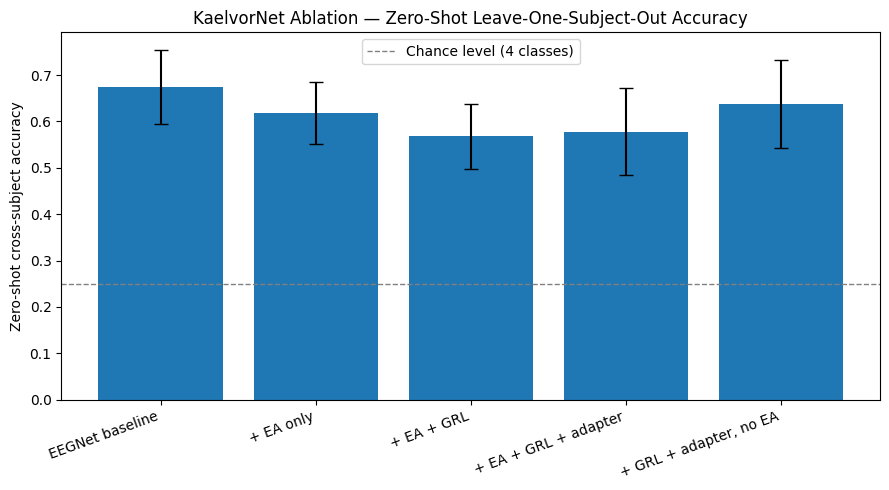

In [13]:
# ==========================================================
# Bar Chart — Mean Accuracy per Variant, with Error Bars
# ==========================================================

fig, ax = plt.subplots(figsize=(9, 5))

variant_names = [v["name"] for v in ABLATION_VARIANTS]
means = summary["Mean_Accuracy"].values
stds = summary["Std_Accuracy"].values

bars = ax.bar(variant_names, means, yerr=stds, capsize=5)

ax.set_ylabel("Zero-shot cross-subject accuracy")
ax.set_title("KaelvorNet Ablation — Zero-Shot Leave-One-Subject-Out Accuracy")
ax.axhline(0.25, linestyle="--", color="gray", linewidth=1, label="Chance level (4 classes)")
ax.legend()
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "kaelvornet_ablation_chart.png", dpi=150)
plt.show()